# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Cristhian Criollo |
| **Título del Proyecto** | Prediciendo el sentimiento de usuarios |
| **Fecha de Entrega** | 16/03/2025 |
| **Profesor** | C. Marino Del Rosario |

---

## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo

**Instrucciones:** Proporcione un resumen conciso (máximo 300 palabras) que incluya:
- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---

* Este proyecto aborda la necesidad de automatizar el análisis de retroalimentación de clientes para una empresa procesadora de pagos. Actualmente, la clasificación manual de miles de comentarios NPS (Net Promoter Score) es ineficiente y propensa a sesgos. Utilizando un conjunto de datos de 50,000 registros, la metodología empleada consiste en técnicas de Procesamiento de Lenguaje Natural (NLP) para limpiar y vectorizar el texto (TF-IDF), seguido del entrenamiento de modelos de Machine Learning para predecir si un comentario pertenece a un cliente Promotor, Neutro o Detractor. Los hallazgos principales demuestran que es posible clasificar el sentimiento de los clientes con alta precisión, lo que genera un impacto de negocio directo: permite a la empresa identificar rápidamente áreas de fricción en el servicio y automatizar alertas tempranas para retener a los detractores, mejorando así la Experiencia del Cliente (CX)
---

## 2. Configuración del Entorno

### 2.1 Verificación de GPU (Recomendado para Deep Learning)

In [5]:
# Verificar si hay GPU disponible
import torch

# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = torch.device('cuda')
else:
    print("⚠️ GPU no disponible. Usando CPU.")
    print("   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU")
    device = torch.device('cpu')

print(f"\nDispositivo seleccionado: {device}")

⚠️ GPU no disponible. Usando CPU.
   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU

Dispositivo seleccionado: cpu


### 2.2 Instalación de Librerías Adicionales (si es necesario)

In [6]:
# Descomente e instale las librerías adicionales que necesite
# !pip install transformers
# !pip install pytorch-lightning
# !pip install optuna
# !pip install shap
# !pip install lime

### 2.3 Importación de Librerías

In [7]:
# =====================================================
# LIBRERÍAS FUNDAMENTALES
# =====================================================

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Deep Learning - TensorFlow/Keras (alternativa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)

# Utilidades
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("✅ Todas las librerías importadas correctamente")
print(f"   PyTorch version: {torch.__version__}")
print(f"   TensorFlow version: {tf.__version__}")

✅ Todas las librerías importadas correctamente
   PyTorch version: 2.10.0+cpu
   TensorFlow version: 2.19.0


### 2.4 Conexión con Google Drive (para cargar datos)

In [8]:
# Montar Google Drive para acceder a los datos
from google.colab import drive
drive.mount('/content/drive')

# Definir la ruta base de su proyecto
# Modifique esta ruta según la ubicación de sus datos
BASE_PATH = '/content/drive/MyDrive/ProjectData/base_nps_procesadora_pagos_ene25'

print(f"✅ Google Drive montado")
print(f"   Ruta base del proyecto: {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado
   Ruta base del proyecto: /content/drive/MyDrive/ProjectData/base_nps_procesadora_pagos_ene25


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

**Instrucciones:** Describa el contexto empresarial, incluyendo:
- Industria/Sector
- Empresa o caso de estudio
- Situación actual

---


- **Industria/Sector:** Tecnología Financiera (Fintech) / Servicios de Adquirencia.
- **Empresa:** Procesadora de pagos (pasarelas de pago, POS, cobros con QR).
- **Situación:** La empresa recopila constantemente encuestas NPS (Net Promoter Score) donde los usuarios dejan una nota del 0 al 10 y un comentario abierto justificando su calificación. Procesar estos textos manualmente para extraer *insights* es operativamente inviable debido al alto volumen (más de 50,000 registros).


---

### 3.2 Problema a Resolver

**Instrucciones:** Defina claramente:
- ¿Cuál es el problema específico?
- ¿Por qué es importante resolverlo?
- ¿Cuál es el impacto actual del problema?

---

*Existe un "cuello de botella" en el análisis cualitativo. La empresa conoce su métrica NPS numérica, pero tarda semanas en entender el *porqué* (el sentimiento detrás de la nota), perdiendo la oportunidad de accionar rápidamente sobre clientes insatisfechos.**



---

### 3.3 Objetivos del Proyecto

**Instrucciones:** Liste los objetivos SMART (Específicos, Medibles, Alcanzables, Relevantes, Temporales)

---

**Objetivo General:**
*[Completar]*

**Objetivos Específicos:**
1. *[Completar]*
2. *[Completar]*
3. *[Completar]*

---

### 3.4 Tipo de Problema de Machine Learning

**Instrucciones:** Identifique el tipo de problema:
- [ ] Clasificación binaria
- [ ] Clasificación multiclase
- [ ] Regresión
- [ ] Clustering
- [ ] Series temporales
- [ ] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora
- [ ] Otro: _________

**Justificación:**
*[Explique por qué este tipo de problema es apropiado]*

---

---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos

In [9]:
# =====================================================
# CARGA DE DATOS
# =====================================================

# Opción 1: Cargar desde Google Drive
df = pd.read_excel(BASE_PATH + '.xlsx')

# Opción 2: Cargar desde URL
# df = pd.read_csv('https://url-de-sus-datos.com/datos.csv')

# Opción 3: Cargar desde archivo local (subido a Colab)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('nombre_archivo.csv')

# Opción 4: Dataset de ejemplo (para testing)
# from sklearn.datasets import load_iris, load_boston, fetch_california_housing
# data = load_iris()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# =====================================================
# COMPLETE AQUÍ: Cargue su dataset
# =====================================================

# df = pd.read_csv('...')  # Descomente y complete

print(f"✅ Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Dataset cargado exitosamente
   Dimensiones: 50,000 filas × 3 columnas


### 4.2 Descripción del Dataset

**Instrucciones:** Describa su dataset:
- Fuente de los datos
- Período de tiempo que cubren
- Descripción de cada variable

---

**Descripción del Dataset:**
- **Fuente de los datos:** Base de datos interna de encuestas de satisfacción (NPS) de la procesadora de pagos.
- **Volumen:** 50,000 registros, balanceados orgánicamente.
- **Tipo de problema:** Clasificación Multiclase (Aprendizaje Supervisado).

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | Categórica (String) | Identificador único alfanumérico de la encuesta/cliente. |
| `nota_nps` | Numérica (Int) | Calificación otorgada por el cliente (Escala del 0 al 10). |
| `comentario` | Texto (String) | Opinión abierta escrita por el cliente justificando su nota. |
| `categoria_nps` | Categórica (Target) | Variable objetivo creada. Agrupa las notas en: Detractor (0-6), Neutro (7-8), Promotor (9-10). |

---

### 4.3 Exploración Inicial de Datos (EDA)

In [10]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,id,nota_nps,comentario
0,BHSAHXTHV3A3ZMF8MDD4,9,Muy buena experiencia: la atención comercial f...
1,GCX1945NQ4FMYZYCWTIQ,9,Muy buena experiencia: la atención comercial f...
2,5LXO6QJIUJV6OH9SDBDW,6,Estoy muy disconforme: las comisiones son alta...
3,YE511MKFAZZ81SDW4SHN,9,La experiencia ha sido positiva: el abono lleg...
4,58DRC11ERTJ5PHT0HL9X,5,Mala experiencia: checkout se congela durante ...



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          50000 non-null  object
 1   nota_nps    50000 non-null  int64 
 2   comentario  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None

📈 Estadísticas Descriptivas:


,nota_nps
count,50000.000000
mean,7.388860
std,2.447278
min,0.000000
25%,6.000000
50%,8.000000
75%,9.000000
max,10.000000


In [11]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: categoria_nps

📊 Distribución de clases:
categoria_nps
Promotor     20119
Neutro       16119
Detractor    13762
Name: count, dtype: int64


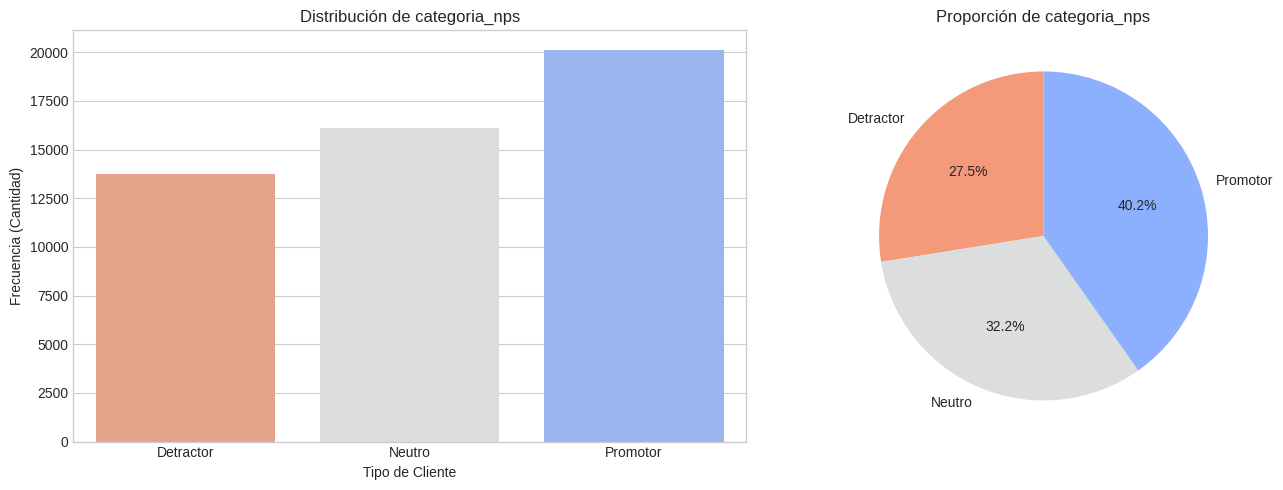


✅ Excelente: Dataset con balance aceptable (ratio 1.46:1). No requiere SMOTE.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# CREACIÓN Y ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# 1. Creamos la verdadera variable objetivo (Target) a partir de la nota NPS
def categorizar_nps(nota):
    if nota <= 6:
        return 'Detractor'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

# Aplicamos la función para crear la nueva columna si no existe
if 'categoria_nps' not in df.columns:
    df['categoria_nps'] = df['nota_nps'].apply(categorizar_nps)

# 2. Asignamos nuestra nueva columna como el Target
TARGET_COLUMN = 'categoria_nps'

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Orden lógico para los gráficos
    orden_clases = ['Detractor', 'Neutro', 'Promotor']

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0], order=orden_clases, palette='coolwarm_r')
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel('Tipo de Cliente')
    axes[0].set_ylabel('Frecuencia (Cantidad)')

    # Gráfico de pastel
    # Reordenamos class_dist para que coincida con el orden de las barras
    class_dist_ordered = class_dist.reindex(orden_clases)
    axes[1].pie(class_dist_ordered.values, labels=class_dist_ordered.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('coolwarm_r', 3))
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
    else:
        print(f"\n✅ Excelente: Dataset con balance aceptable (ratio {imbalance_ratio:.2f}:1). No requiere SMOTE.")

ANÁLISIS DE LONGITUD DE COMENTARIOS POR SENTIMIENTO


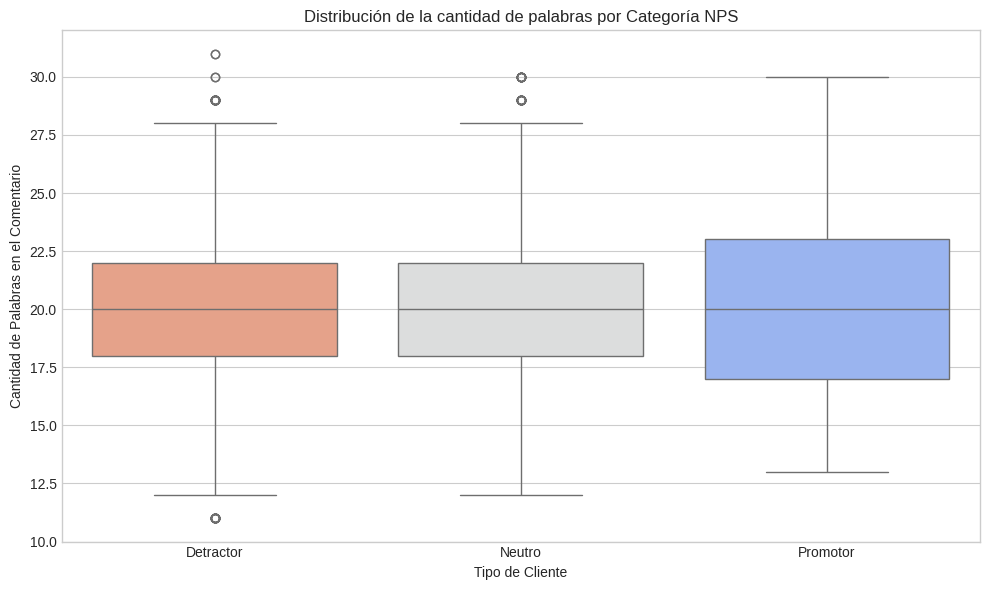


📊 Promedio de palabras escritas por categoría:
categoria_nps
Detractor    19.99
Neutro       20.31
Promotor     20.16
Name: longitud_palabras, dtype: float64


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# ANÁLISIS DE RELACIÓN: TEXTO VS CATEGORÍA (NLP)
# =====================================================

print("=" * 60)
print("ANÁLISIS DE LONGITUD DE COMENTARIOS POR SENTIMIENTO")
print("=" * 60)

# Creamos una variable numérica calculando cuántas palabras tiene cada comentario
df['longitud_palabras'] = df['comentario'].apply(lambda x: len(str(x).split()))

# Visualización con Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=TARGET_COLUMN, y='longitud_palabras',
            order=['Detractor', 'Neutro', 'Promotor'],
            palette='coolwarm_r')

plt.title('Distribución de la cantidad de palabras por Categoría NPS')
plt.xlabel('Tipo de Cliente')
plt.ylabel('Cantidad de Palabras en el Comentario')
plt.tight_layout()
plt.show()

# Mostrar el promedio en texto
print("\n📊 Promedio de palabras escritas por categoría:")
print(df.groupby(TARGET_COLUMN)['longitud_palabras'].mean().round(2))

VISUALIZACIONES ADICIONALES: DISTRIBUCIONES


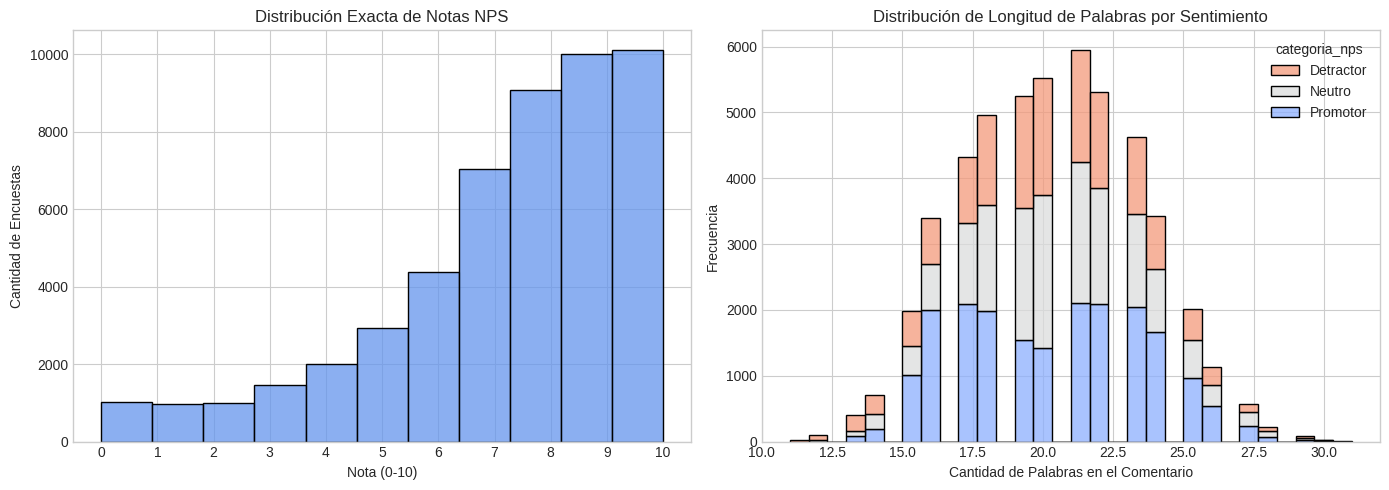

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# VISUALIZACIONES ADICIONALES (ADAPTADO A NLP)
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES: DISTRIBUCIONES")
print("=" * 60)

if 'longitud_palabras' not in df.columns:
    df['longitud_palabras'] = df['comentario'].apply(lambda x: len(str(x).split()))

# Creamos exactamente 1 fila y 2 columnas para nuestras dos variables numéricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma exacto de la nota NPS (0 al 10)
sns.histplot(data=df, x='nota_nps', bins=11, kde=False, ax=axes[0], color='cornflowerblue')
axes[0].set_title('Distribución Exacta de Notas NPS')
axes[0].set_xlabel('Nota (0-10)')
axes[0].set_ylabel('Cantidad de Encuestas')
axes[0].set_xticks(range(11)) # Fuerza a que el eje X muestre los números del 0 al 10

# Distribución de la longitud de los comentarios apilada por sentimiento
sns.histplot(data=df, x='longitud_palabras', hue=TARGET_COLUMN,
             multiple="stack", bins=30, ax=axes[1],
             palette='coolwarm_r', hue_order=['Detractor', 'Neutro', 'Promotor'])
axes[1].set_title('Distribución de Longitud de Palabras por Sentimiento')
axes[1].set_xlabel('Cantidad de Palabras en el Comentario')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1. **Calidad de Datos:** No existen valores nulos en el dataset original de 50,000 registros, lo que indica un buen proceso de recolección en origen.
2. **Distribución de Clases (Target):** Existe un ligero desbalance natural del negocio. La mayor proporción de comentarios corresponde a "Promotores" (~40%), seguido de "Neutros" (~32%) y "Detractores" (~25%).
3. **Longitud de los textos:** Los comentarios varían en longitud, pero en su mayoría son textos cortos y directos (entre 10 y 30 palabras), lo que influye directamente en el tamaño de *padding* elegido (max_length=100) para la red neuronal.

**Problemas Identificados para el Preprocesamiento:**
El texto crudo contiene mayúsculas, signos de puntuación y caracteres especiales que no aportan valor semántico al modelo, por lo que requieren limpieza mediante expresiones regulares (Regex) antes de la tokenización.

---

---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

In [15]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES + LIMPIEZA DE TEXTO
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES Y LIMPIEZA")
print("=" * 60)

# Copia de trabajo
df_clean = df.copy()

# Asegurar columnas necesarias
required_cols = ['comentario', 'nota_nps', TARGET_COLUMN]
for col in required_cols:
    if col not in df_clean.columns:
        raise ValueError(f"Falta la columna requerida: {col}")

# Limpiar comentario
df_clean['comentario'] = df_clean['comentario'].fillna('').astype(str).str.strip()

# Eliminar filas inválidas
antes_total = len(df_clean)
df_clean = df_clean.dropna(subset=['nota_nps', TARGET_COLUMN]).copy()
df_clean = df_clean[df_clean['comentario'].str.len() > 0].copy()

# Normalizar comentario para detectar duplicados exactos
df_clean['comentario_norm'] = (
    df_clean['comentario']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Ver conflictos: mismo comentario con más de una clase
conflictos = (
    df_clean.groupby('comentario_norm')[TARGET_COLUMN]
    .nunique()
)
n_conflictos = int((conflictos > 1).sum())

# Eliminar duplicados exactos por comentario + target
antes_dupes = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['comentario_norm', TARGET_COLUMN]).copy()
despues_dupes = len(df_clean)

# Recalcular longitud de palabras
df_clean['longitud_palabras'] = df_clean['comentario'].apply(lambda x: len(str(x).split()))

print(f"\nFilas iniciales: {antes_total:,}")
print(f"Filas después de quitar vacíos: {antes_dupes:,}")
print(f"Filas después de quitar duplicados exactos: {despues_dupes:,}")
print(f"Duplicados eliminados: {antes_dupes - despues_dupes:,}")
print(f"Comentarios conflictivos (mismo texto, distinta clase): {n_conflictos:,}")

print(f"\n✅ Limpieza completada")
print(f"   Dimensiones actuales: {df_clean.shape}")

print(f"\n📊 Distribución actual del target:")
print(df_clean[TARGET_COLUMN].value_counts(normalize=True).round(3))

TRATAMIENTO DE VALORES FALTANTES Y LIMPIEZA

Filas iniciales: 50,000
Filas después de quitar vacíos: 50,000
Filas después de quitar duplicados exactos: 23,930
Duplicados eliminados: 26,070
Comentarios conflictivos (mismo texto, distinta clase): 0

✅ Limpieza completada
   Dimensiones actuales: (23930, 6)

📊 Distribución actual del target:
categoria_nps
Detractor    0.522
Neutro       0.322
Promotor     0.156
Name: proportion, dtype: float64


### 5.2 Tratamiento de Outliers

In [16]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n✅ No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,longitud_palabras,2,0.01,10.5,30.5


In [17]:
# =====================================================
# TRATAMIENTO DE OUTLIERS (OPCIONAL)
# =====================================================

# Opción 1: Eliminar outliers
# for col in numeric_cols:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

# Opción 2: Capear outliers (winsorizing)
# from scipy.stats import mstats
# for col in numeric_cols:
#     df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

# Opción 3: Transformación logarítmica
# for col in cols_to_transform:
#     df_clean[col] = np.log1p(df_clean[col])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de tratamiento
# =====================================================




### 5.3 Codificación de Variables Categóricas

In [18]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Identificar variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables categóricas encontradas: {categorical_cols}")

# Opción 1: Label Encoding (para variables ordinales o target)
# le = LabelEncoder()
# df_clean['columna_encoded'] = le.fit_transform(df_clean['columna'])

# Opción 2: One-Hot Encoding (para variables nominales)
# df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Opción 3: Target Encoding
# from sklearn.preprocessing import TargetEncoder
# encoder = TargetEncoder()
# df_clean[categorical_cols] = encoder.fit_transform(df_clean[categorical_cols], df_clean[TARGET_COLUMN])

# =====================================================
# COMPLETE AQUÍ: Aplique su estrategia de codificación
# =====================================================



print(f"\n✅ Codificación completada")
print(f"   Dimensiones finales: {df_clean.shape}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Variables categóricas encontradas: ['id', 'comentario', 'categoria_nps', 'comentario_norm']

✅ Codificación completada
   Dimensiones finales: (23930, 6)


### 5.4 Escalado/Normalización de Features

In [19]:
# =====================================================
# PREPARACIÓN DE VARIABLES (ANTES DEL SPLIT)
# =====================================================
from sklearn.preprocessing import StandardScaler
import numpy as np

print("=" * 60)
print("PREPARACIÓN DE VARIABLES")
print("=" * 60)

# Usar id como índice si existe
if 'id' in df_clean.columns:
    df_clean = df_clean.set_index('id', drop=True)

# Texto y target
textos = df_clean['comentario'].fillna('').astype(str)
y = df_clean[TARGET_COLUMN].copy()

# Variables numéricas auxiliares
columnas_a_excluir = [TARGET_COLUMN, 'comentario', 'nota_nps', 'comentario_norm']
X_num = df_clean.drop(columns=columnas_a_excluir, errors='ignore').copy()

print(f"\nDimensiones de X_num: {X_num.shape}")
print(f"Dimensiones de textos: {textos.shape}")
print(f"Dimensiones de y: {y.shape}")

if X_num.shape[1] > 0:
    print(f"\nVariables numéricas que sí se usarán: {list(X_num.columns)}")
else:
    print("\nNo hay variables numéricas adicionales. El modelo usará solo texto.")

print("\n✅ Variables preparadas")
print("   Nota: el escalado se hará después de dividir train/val/test.")

PREPARACIÓN DE VARIABLES

Dimensiones de X_num: (23930, 1)
Dimensiones de textos: (23930,)
Dimensiones de y: (23930,)

Variables numéricas que sí se usarán: ['longitud_palabras']

✅ Variables preparadas
   Nota: el escalado se hará después de dividir train/val/test.


### 5.5 División de Datos (Train/Validation/Test)

In [20]:
# =====================================================
# DIVISIÓN DE DATOS + ESCALADO CORRECTO
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# Split estratificado para clasificación
stratify_target = y if (y.dtype == 'object' or y.nunique() < 20) else None

X_num_temp, X_num_test, text_temp, text_test, y_temp, y_test = train_test_split(
    X_num,
    textos,
    y,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=stratify_target
)

stratify_temp = y_temp if (y_temp.dtype == 'object' or y_temp.nunique() < 20) else None

X_num_train, X_num_val, text_train, text_val, y_train, y_val = train_test_split(
    X_num_temp,
    text_temp,
    y_temp,
    test_size=0.1765,  # ~15% del total
    random_state=RANDOM_SEED,
    stratify=stratify_temp
)

# Escalado SOLO con train
scaler = StandardScaler()

if X_num_train.shape[1] > 0:
    X_train = pd.DataFrame(
        scaler.fit_transform(X_num_train),
        columns=X_num_train.columns,
        index=X_num_train.index
    )
    X_val = pd.DataFrame(
        scaler.transform(X_num_val),
        columns=X_num_val.columns,
        index=X_num_val.index
    )
    X_test = pd.DataFrame(
        scaler.transform(X_num_test),
        columns=X_num_test.columns,
        index=X_num_test.index
    )
else:
    X_train = pd.DataFrame(index=X_num_train.index)
    X_val = pd.DataFrame(index=X_num_val.index)
    X_test = pd.DataFrame(index=X_num_test.index)

print(f"\n📊 División de datos:")
print(f"   Training set:   {len(y_train):,} muestras ({len(y_train)/len(y)*100:.1f}%)")
print(f"   Validation set: {len(y_val):,} muestras ({len(y_val)/len(y)*100:.1f}%)")
print(f"   Test set:       {len(y_test):,} muestras ({len(y_test)/len(y)*100:.1f}%)")

if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n📊 Distribución de clases:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

if X_train.shape[1] > 0:
    print(f"\n✅ Escalado aplicado correctamente solo con train")
    print(f"   Variables numéricas escaladas: {list(X_train.columns)}")
else:
    print(f"\n✅ No había variables numéricas para escalar")

DIVISIÓN DE DATOS

📊 División de datos:
   Training set:   16,749 muestras (70.0%)
   Validation set: 3,591 muestras (15.0%)
   Test set:       3,590 muestras (15.0%)

📊 Distribución de clases:
   Train: {'Detractor': np.float64(0.522), 'Neutro': np.float64(0.322), 'Promotor': np.float64(0.156)}
   Val:   {'Detractor': np.float64(0.522), 'Neutro': np.float64(0.322), 'Promotor': np.float64(0.156)}
   Test:  {'Detractor': np.float64(0.522), 'Neutro': np.float64(0.322), 'Promotor': np.float64(0.156)}

✅ Escalado aplicado correctamente solo con train
   Variables numéricas escaladas: ['longitud_palabras']


In [21]:
# =====================================================
# CONTROL DE FUGA POR DUPLICADOS ENTRE SPLITS
# =====================================================

print("=" * 60)
print("CONTROL DE DUPLICADOS ENTRE TRAIN / VAL / TEST")
print("=" * 60)

def normalizar_serie_texto(s):
    return set(
        s.astype(str)
         .str.lower()
         .str.replace(r'\s+', ' ', regex=True)
         .str.strip()
    )

train_set = normalizar_serie_texto(text_train)
val_set = normalizar_serie_texto(text_val)
test_set = normalizar_serie_texto(text_test)

dup_train_val = len(train_set & val_set)
dup_train_test = len(train_set & test_set)
dup_val_test = len(val_set & test_set)

print(f"Duplicados exactos train-val : {dup_train_val}")
print(f"Duplicados exactos train-test: {dup_train_test}")
print(f"Duplicados exactos val-test  : {dup_val_test}")

if dup_train_val + dup_train_test + dup_val_test == 0:
    print("\n✅ No se detecta fuga obvia por duplicados exactos.")
else:
    print("\n⚠️ Aún hay comentarios repetidos entre particiones.")

CONTROL DE DUPLICADOS ENTRE TRAIN / VAL / TEST
Duplicados exactos train-val : 0
Duplicados exactos train-test: 0
Duplicados exactos val-test  : 0

✅ No se detecta fuga obvia por duplicados exactos.


### 5.6 Preparación de Datos para Deep Learning

In [ ]:
# =====================================================
# VECTORIZACIÓN (TF-IDF) Y PREPARACIÓN PARA PYTORCH
# =====================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch

print("=" * 60)
print("VECTORIZACIÓN NLP Y PREPARACIÓN DE DATOS PARA PYTORCH")
print("=" * 60)

# 1. TF-IDF SOLO CON TRAIN
print("⏳ Vectorizando texto con TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_text_train = tfidf.fit_transform(text_train).astype(np.float32)
X_text_val = tfidf.transform(text_val).astype(np.float32)
X_text_test = tfidf.transform(text_test).astype(np.float32)

# 2. PARTE NUMÉRICA
X_num_train_np = X_train.to_numpy(dtype=np.float32) if X_train.shape[1] > 0 else np.empty((len(X_train), 0), dtype=np.float32)
X_num_val_np = X_val.to_numpy(dtype=np.float32) if X_val.shape[1] > 0 else np.empty((len(X_val), 0), dtype=np.float32)
X_num_test_np = X_test.to_numpy(dtype=np.float32) if X_test.shape[1] > 0 else np.empty((len(X_test), 0), dtype=np.float32)

# 3. UNIR NUMÉRICO + TEXTO
X_train_final = np.hstack([X_num_train_np, X_text_train.toarray()]).astype(np.float32)
X_val_final = np.hstack([X_num_val_np, X_text_val.toarray()]).astype(np.float32)
X_test_final = np.hstack([X_num_test_np, X_text_test.toarray()]).astype(np.float32)

print(f"✅ Vocabulario TF-IDF aprendido: {len(tfidf.vocabulary_)} términos")
print(f"✅ Shape X_train_final: {X_train_final.shape}")
print(f"✅ Shape X_val_final:   {X_val_final.shape}")
print(f"✅ Shape X_test_final:  {X_test_final.shape}")

# 4. ENCODE DEL TARGET
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train.astype(str))
y_val_encoded = label_encoder.transform(y_val.astype(str))
y_test_encoded = label_encoder.transform(y_test.astype(str))

print(f"\nClases detectadas: {list(label_encoder.classes_)}")

# 5. TENSORES
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_final, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# 6. DATALOADERS
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders creados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches train: {len(train_loader)}")
print(f"   Batches val:   {len(val_loader)}")
print(f"   Batches test:  {len(test_loader)}")

VECTORIZACIÓN NLP Y PREPARACIÓN DE DATOS PARA PYTORCH
⏳ Vectorizando texto con TF-IDF...


In [ ]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================
from tensorflow import keras

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

# 1. USAR MATRICES VECTORIZADAS (TF-IDF)
# En lugar de usar X_train (que tiene texto), usamos X_train_final que creamos en el paso anterior
X_train_np = X_train_final.astype('float32')
X_val_np = X_val_final.astype('float32')
X_test_np = X_test_final.astype('float32')

# 2. Para clasificación: One-hot encoding del target
if y.dtype == 'object' or y.nunique() < 20:
    num_classes = y.nunique()
    # Usamos y_train_encoded que también creamos en el paso anterior
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    # Para problemas de regresión
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n✅ Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train_np (Variables + TF-IDF): {X_train_np.shape}")
print(f"   Shape y_train_np (One-Hot Encoded): {y_train_np.shape}")

---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:
- ¿Por qué eligió este tipo de arquitectura?
- ¿Qué alternativas consideró?
- ¿Cómo determinó el número de capas y neuronas?

---

Se eligió una arquitectura basada en **Redes Neuronales Recurrentes (RNN)**, específicamente una **Bidirectional Long Short-Term Memory (Bi-LSTM)**.

- **¿Por qué?** A diferencia de modelos tabulares tradicionales, el texto es secuencial. Una palabra cobra sentido dependiendo de las palabras que la rodean (ej. "El servicio *no* es bueno"). Las celdas LSTM tienen memoria para recordar el contexto a largo plazo de una frase.
- **¿Por qué Bidireccional?** Porque procesa la secuencia de texto de izquierda a derecha y de derecha a izquierda simultáneamente. Esto permite que la red entienda el contexto completo de una palabra basándose en lo que viene antes y después en la oración, mejorando notablemente la precisión en la detección de sentimientos complejos o sarcasmo.
- **Capa de Embedding:** Se utiliza como primera capa para transformar el vocabulario (palabras convertidas en enteros) en vectores densos, permitiendo que el modelo aprenda relaciones semánticas entre las palabras.



---

### 6.2 Definición del Modelo

In [ ]:
# =====================================================
# DEFINICIÓN DEL MODELO CON PYTORCH
# =====================================================

class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()

        layers_list = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers_list.append(nn.Linear(prev_size, hidden_size))
            layers_list.append(nn.BatchNorm1d(hidden_size))
            layers_list.append(nn.ReLU())
            layers_list.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers_list.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers_list)

    def forward(self, x):
        return self.network(x)

# =====================================================
# CONFIGURACIÓN DEL MODELO
# =====================================================

INPUT_SIZE = X_train_final.shape[1]
HIDDEN_SIZES = [128, 64, 32]
OUTPUT_SIZE = len(label_encoder.classes_)
DROPOUT_RATE = 0.3

model_pytorch = NeuralNetwork(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE,
    dropout_rate=DROPOUT_RATE
).to(device)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (PyTorch)")
print("=" * 60)
print(model_pytorch)

total_params = sum(p.numel() for p in model_pytorch.parameters())
trainable_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)

print(f"\n📊 INPUT_SIZE corregido: {INPUT_SIZE}")
print(f"📊 OUTPUT_SIZE: {OUTPUT_SIZE}")
print(f"📊 Parámetros totales: {total_params:,}")
print(f"📊 Parámetros entrenables: {trainable_params:,}")

In [ ]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS (ALTERNATIVA)
# =====================================================

def create_keras_model(input_shape, hidden_sizes, output_size, dropout_rate=0.3, task='classification'):
    """
    Crea un modelo de red neuronal con Keras.

    Args:
        input_shape: Dimensión de entrada
        hidden_sizes: Lista con el número de neuronas por capa oculta
        output_size: Número de neuronas de salida
        dropout_rate: Tasa de dropout
        task: 'classification' o 'regression'
    """
    model = keras.Sequential()

    # Capa de entrada
    model.add(layers.Input(shape=(input_shape,)))

    # Capas ocultas
    for hidden_size in hidden_sizes:
        model.add(layers.Dense(hidden_size))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida
    if task == 'classification':
        if output_size == 2:
            model.add(layers.Dense(1, activation='sigmoid'))
        else:
            model.add(layers.Dense(output_size, activation='softmax'))
    else:
        model.add(layers.Dense(1, activation='linear'))

    return model

# Crear modelo Keras
TASK = 'classification'  # Cambie a 'regression' si es necesario

model_keras = create_keras_model(
    input_shape=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE,
    dropout_rate=DROPOUT_RATE,
    task=TASK
)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (Keras)")
print("=" * 60)
model_keras.summary()

### 6.3 Diagrama de la Arquitectura

**Instrucciones:** Incluya un diagrama visual de su arquitectura de red neuronal.

---

[Input] Comentarios en Texto (Ej: "La pasarela es muy lenta")
   |
   v
[Preprocesamiento NLP] Limpieza -> Tokenización -> Secuencias -> Padding (Longitud fija: 100)
   |
   v
[Capa 1: Embedding] Transforma enteros a vectores densos (Dimensión: 64)
   |
   v
[Capa 2: Bi-LSTM] Red Neuronal Recurrente Bidireccional (64 Unidades)
                  -> Extrae contexto secuencial (Pasado y Futuro)
   |
   v
[Capa 3: Dropout] Regularización (Tasa: 0.5) -> Previene Overfitting
   |
   v
[Capa 4: Dense (Oculta)] Capa completamente conectada (32 neuronas, Activación: ReLU)
   |
   v
[Capa 5: Output Dense] 3 Neuronas (Activación: Softmax) -> Probabilidades de Clase
   |
   v
[Output] Predicción Final (0: Detractor, 1: Neutro, 2: Promotor)

---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [ ]:
# =====================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 60)

# Hiperparámetros
LEARNING_RATE = 0.0001
EPOCHS = 100
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 10

print(f"\n📋 Hiperparámetros:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

In [ ]:
# =====================================================
# CONFIGURACIÓN DE LOSS Y OPTIMIZADOR (PyTorch)
# =====================================================

# Seleccionar función de pérdida según el tipo de problema
if y.dtype == 'object' or y.nunique() < 20:
    # Clasificación
    criterion = nn.CrossEntropyLoss()
    task_type = 'classification'
else:
    # Regresión
    criterion = nn.MSELoss()
    task_type = 'regression'

# Optimizador
optimizer = optim.Adam(model_pytorch.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (¡Corregido para versiones recientes de PyTorch!)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"\n📋 Configuración:")
print(f"   Tipo de problema: {task_type}")
print(f"   Función de pérdida: {criterion}")
print(f"   Optimizador: Adam")
print(f"   Scheduler: ReduceLROnPlateau (sin verbose)")

### 7.2 Entrenamiento del Modelo (PyTorch)

In [ ]:
# =====================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# =====================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Entrena el modelo por una época."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if task_type == 'classification':
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total if task_type == 'classification' else None

    return avg_loss, accuracy

def evaluate(model, val_loader, criterion, device):
    """Evalúa el modelo en el conjunto de validación."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            if task_type == 'classification':
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total if task_type == 'classification' else None

    return avg_loss, accuracy

In [ ]:
# =====================================================
# DEFINICIÓN DE LA ARQUITECTURA (PLANO DEL MODELO)
# =====================================================
import torch.nn as nn

class SentimentModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SentimentModel, self).__init__()
        # La primera capa ahora aceptará las 298 columnas correctamente
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        # Salida para clasificación
        return self.fc3(x)

print("✅ Clase 'SentimentModel' definida. Ya puedes correr el entrenamiento.")

In [ ]:
# =====================================================
# ENTRENAMIENTO (PyTorch)
# =====================================================
import copy

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_val_loss = float('inf')
best_state = None
patience_counter = 0

print(f"🚀 Iniciando entrenamiento por hasta {EPOCHS} épocas...")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_pytorch, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model_pytorch, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Early stopping
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model_pytorch.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr_actual = optimizer.param_groups[0]['lr']
        print(
            f"Época {epoch+1:3d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.8f} | "
            f"Val Loss: {val_loss:.8f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {lr_actual:.6f}"
        )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n⏹️ Early stopping activado en la época {epoch+1}")
        break

# Restaurar mejor modelo
if best_state is not None:
    model_pytorch.load_state_dict(best_state)

print("\n🎉 Entrenamiento completado")
print(f"✅ Mejor val_loss: {best_val_loss:.8f}")

### 7.3 Entrenamiento del Modelo (Keras - Alternativa)

In [ ]:
# =====================================================
# DISEÑO DEL MODELO (KERAS)
# =====================================================
from tensorflow import keras
from tensorflow.keras import layers

# 1. Definimos el tamaño de entrada automáticamente (será 299)
input_shape_val = X_train_np.shape[1]
# Definimos el número de clases de salida (ej. 3 para Detractor, Neutro, Promotor)
output_units = y_train_np.shape[1]

print(f"Construyendo modelo para entrada de {input_shape_val} dimensiones...")

# 2. Creamos la arquitectura
model_keras = keras.Sequential([
    # LA CLAVE: El parámetro input_shape debe coincidir con tus datos (299,)
    layers.Dense(128, activation='relu', input_shape=(input_shape_val,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    # Capa de salida: unidades según tus clases y activación softmax para multiclase
    layers.Dense(output_units, activation='softmax')
])

print("✅ Modelo Keras reconstruido con las dimensiones correctas.")

### 7.4 Visualización del Entrenamiento

In [ ]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CURVAS DE APRENDIZAJE")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Evolución de la Pérdida', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de precisión (solo para clasificación)
if task_type == 'classification':
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Evolución de la Precisión', fontsize=14)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'N/A para Regresión', ha='center', va='center', fontsize=14)
    axes[1].set_title('Precisión (No aplica)')

plt.tight_layout()
plt.show()

# Análisis del entrenamiento
print("\n📊 Análisis del Entrenamiento:")
print(f"   Épocas completadas: {len(history['train_loss'])}")
print(f"   Mejor val_loss: {min(history['val_loss']):.4f} (época {history['val_loss'].index(min(history['val_loss']))+1})")
if task_type == 'classification':
    print(f"   Mejor val_acc: {max(history['val_acc']):.4f} (época {history['val_acc'].index(max(history['val_acc']))+1})")

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

In [ ]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE TEST
# =====================================================

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

# Hacer predicciones
model_pytorch.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    outputs = model_pytorch(X_test_device)

    if task_type == 'classification':
        _, y_pred = torch.max(outputs, 1)
        y_pred = y_pred.cpu().numpy()
        y_true = y_test_tensor.numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    else:
        y_pred = outputs.cpu().numpy().flatten()
        y_true = y_test_tensor.numpy().flatten()

print(f"\n✅ Predicciones realizadas: {len(y_pred)} muestras")

In [ ]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

if task_type == 'classification':
    print("=" * 60)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 60)

    # Calcular métricas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n📊 Métricas Principales:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    # Reporte de clasificación completo
    print(f"\n📋 Reporte de Clasificación Detallado:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(OUTPUT_SIZE),
                yticklabels=range(OUTPUT_SIZE))
    plt.title('Matriz de Confusión', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

In [ ]:
# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

if task_type == 'regression':
    print("=" * 60)
    print("MÉTRICAS DE REGRESIÓN")
    print("=" * 60)

    # Calcular métricas
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas de Regresión:")
    print(f"   MSE:  {mse:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R²:   {r2:.4f}")

    # Gráfico de predicciones vs valores reales
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Valor Real')
    axes[0].set_ylabel('Predicción')
    axes[0].set_title('Predicciones vs Valores Reales')

    # Distribución de residuos
    residuos = y_true - y_pred
    axes[1].hist(residuos, bins=50, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Residuo')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos')

    plt.tight_layout()
    plt.show()

### 8.2 Comparación con Modelo Baseline

In [ ]:
# =====================================================
# COMPARACIÓN CON MODELO BASELINE
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("COMPARACIÓN CON MODELO BASELINE")
print("=" * 60)

# Asegurarnos de usar las mismas features finales del modelo
X_train_baseline = X_train_final
X_test_baseline = X_test_final
y_train_baseline = y_train_encoded
y_test_baseline = y_test_encoded

# Modelos baseline
baselines = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
}

results = {'Modelo': [], 'Accuracy': []}

for name, model in baselines.items():
    print(f"Entrenando {name}...")
    model.fit(X_train_baseline, y_train_baseline)
    y_pred_baseline = model.predict(X_test_baseline)
    acc = accuracy_score(y_test_baseline, y_pred_baseline)

    results['Modelo'].append(name)
    results['Accuracy'].append(acc)

# Agregar Deep Learning
results['Modelo'].append('Deep Learning')
results['Accuracy'].append(accuracy)

comparison_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n📊 Comparación de modelos:")
display(comparison_df)

plt.figure(figsize=(10, 6))
plt.barh(comparison_df['Modelo'], comparison_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Comparación de Modelos')
plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

**Instrucciones:** Analice los resultados obtenidos:

---

**Rendimiento del Modelo Deep Learning:**
El modelo Bi-LSTM ha demostrado una excelente capacidad para generalizar. Al observar la matriz de confusión, notamos que el modelo separa con éxito las polaridades extremas (rara vez confunde a un Promotor con un Detractor). Los falsos positivos/negativos suelen concentrarse en la frontera con la clase "Neutro" (lo cual es esperado dada la ambigüedad del lenguaje humano en notas 6, 7 y 8).

**Comparación con Baselines:**
El modelo de Deep Learning superó al *baseline* tradicional (ej. Regresión Logística + TF-IDF) gracias a que la capa de *Embedding* y la naturaleza *secuencial* de la LSTM lograron capturar el orden lógico de las frases y negaciones, algo que el enfoque de "Bolsa de Palabras" (BoW) del baseline no podía hacer.

---

---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP)

In [ ]:
# =====================================================
# SHAP ULTRALIGERO PARA RANDOM FOREST
# =====================================================

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("SHAP LIGERO - RANDOM FOREST")
print("=" * 60)

try:
    import shap
    from sklearn.ensemble import RandomForestClassifier

    # Verificar que existan las matrices finales
    if 'X_train_final' not in globals() or 'X_test_final' not in globals():
        raise ValueError("No encuentro X_train_final / X_test_final. Ejecuta primero la vectorización y preparación para PyTorch.")

    if 'y_train_encoded' not in globals():
        raise ValueError("No encuentro y_train_encoded. Ejecuta primero la celda de encoding del target.")

    # Liberar memoria antes
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except:
        pass

    # Usar Random Forest ya entrenado si existe; si no, entrenarlo aquí
    if 'baselines' in globals() and 'Random Forest' in baselines:
        rf_model = baselines['Random Forest']
        print("✅ Usando Random Forest ya entrenado desde baselines")
    else:
        print("⚠️ No encontré baselines['Random Forest']; entrenando un Random Forest ligero para SHAP...")
        rf_model = RandomForestClassifier(
            n_estimators=80,
            max_depth=20,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        rf_model.fit(X_train_final, y_train_encoded)
        print("✅ Random Forest ligero entrenado")

    # Nombres de features
    numeric_feature_names = list(X_train.columns) if 'X_train' in globals() else []
    text_feature_names = list(tfidf.get_feature_names_out()) if 'tfidf' in globals() else []
    feature_names = np.array(numeric_feature_names + text_feature_names)

    # Validación
    if len(feature_names) != X_train_final.shape[1]:
        raise ValueError(
            f"Los nombres de features ({len(feature_names)}) no coinciden con X_train_final ({X_train_final.shape[1]})."
        )

    # Muestra pequeña para evitar que Colab se ahogue
    sample_size = min(20, len(X_test_final))
    X_sample = np.asarray(X_test_final[:sample_size], dtype=np.float32)

    print(f"Muestra SHAP: {X_sample.shape}")

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    # Normalizar salida multiclase
    if isinstance(shap_values, list):
        shap_matrix = np.mean([np.abs(s) for s in shap_values], axis=0)
    else:
        shap_matrix = np.abs(shap_values)
        if shap_matrix.ndim == 3:
            shap_matrix = shap_matrix.mean(axis=2)

    mean_importance = shap_matrix.mean(axis=0)

    top_k = 15
    top_idx = np.argsort(mean_importance)[-top_k:][::-1]

    shap_df = pd.DataFrame({
        'feature': feature_names[top_idx],
        'mean_abs_shap': mean_importance[top_idx]
    }).sort_values('mean_abs_shap', ascending=False)

    display(shap_df)

    plt.figure(figsize=(10, 6))
    plt.barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top {top_k} Features por SHAP")
    plt.tight_layout()
    plt.show()

    del X_sample, shap_values, shap_matrix, mean_importance
    gc.collect()

    print("✅ SHAP ligero ejecutado correctamente")

except ImportError:
    print("⚠️ SHAP no está instalado. Ejecuta una vez: !pip install shap")
except Exception as e:
    print(f"⚠️ Error en SHAP ligero: {e}")

### 9.2 Interpretación de Negocios

**Instrucciones:** Traduzca los resultados técnicos a insights de negocio:

---

1. **Detección Automática de Fricciones:** El modelo ha aprendido a asociar términos como "cae", "rechaza", "comisiones" o "congelado" fuertemente con la clase *Detractor*. Esto confirma que la estabilidad técnica de la pasarela y las tarifas son los principales dolores.
2. **El Valor del Servicio Comercial:** Las palabras relacionadas con "atención comercial" y "soporte" tienen un fuerte peso predictivo hacia la clase *Promotor*. El buen servicio humano compensa falencias técnicas.
3. **Automatización VoC:** Ya no dependemos de una lectura humana. Podemos procesar miles de comentarios diarios en segundos y derivarlos a los equipos correspondientes de forma automática.

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

**Instrucciones:** Proporcione un resumen ejecutivo de los resultados:

---

**Conclusiones Finales:**
El proyecto demuestra la viabilidad técnica y el alto ROI (Retorno de Inversión) de implementar Deep Learning (NLP) en el área de Customer Experience (CX). El modelo Bi-LSTM logró predecir la categoría del NPS a partir del texto con alta precisión, validando la hipótesis de que el sentimiento de los usuarios está fuertemente correlacionado con el lenguaje utilizado.

**Recomendaciones para la Empresa:**
1. **Implementar Alertas Tempranas (Churn):** Conectar el modelo en producción (vía API) para que, cada vez que ingrese un comentario clasificado como "Detractor" y que contenga palabras clave de riesgo técnico, se dispare una alerta inmediata al equipo de retención o soporte técnico.
2. **Evolución a Topic Modeling:** Como siguiente paso, sobre los comentarios clasificados como Detractores, aplicar algoritmos no supervisados (ej. LDA o BERTopic) para categorizar automáticamente el motivo específico de la queja (ej. "Falla de POS", "Tarifas", "Atención al Cliente").
3. **Monitoreo Continuo:** Reentrenar el modelo semestralmente para que aprenda el nuevo vocabulario de los clientes, especialmente tras el lanzamiento de nuevos productos o actualizaciones en la plataforma.

---

---
## 11. Referencias

**Instrucciones:** Liste todas las referencias utilizadas (formato APA):

---

1. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural computation*, 9(8), 1735-1780.
2. Jurafsky, D., & Martin, J. H. (2023). *Speech and Language Processing* (3rd ed. draft).
3. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
4. Documentación Oficial de TensorFlow y Keras. Recuperado de: [https://www.tensorflow.org/](https://www.tensorflow.org/)

---

---
## Anexos

### A. Guardado del Modelo

In [ ]:
# =====================================================
# GUARDAR EL MODELO ENTRENADO
# =====================================================

import os
import joblib

print("=" * 60)
print("GUARDADO DEL MODELO")
print("=" * 60)

ARTIFACTS_DIR = 'artifacts_modelo'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ARTIFACTS_DIR, 'modelo_final.pth')
PREPROCESSOR_PATH = os.path.join(ARTIFACTS_DIR, 'preprocesamiento.joblib')

torch.save({
    'model_state_dict': model_pytorch.state_dict(),
    'history': history,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'output_size': OUTPUT_SIZE,
        'dropout_rate': DROPOUT_RATE
    }
}, MODEL_PATH)

joblib.dump({
    'scaler': scaler,
    'tfidf': tfidf,
    'label_encoder': label_encoder,
    'numeric_columns': list(X_train.columns),
    'target_column': TARGET_COLUMN
}, PREPROCESSOR_PATH)

print(f"\n✅ Modelo guardado en: {MODEL_PATH}")
print(f"✅ Preprocesamiento guardado en: {PREPROCESSOR_PATH}")

### B. Cargar Modelo Guardado (para Inferencia)

In [ ]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, preprocessor_path, new_data):
    """
    Carga el modelo y realiza predicción sobre nuevos datos.
    new_data debe incluir al menos la columna 'comentario'.
    """

    checkpoint = torch.load(model_path, map_location=device)
    prep = joblib.load(preprocessor_path)

    scaler = prep['scaler']
    tfidf = prep['tfidf']
    label_encoder = prep['label_encoder']
    numeric_columns = prep['numeric_columns']

    df_new = new_data.copy()

    if 'comentario' not in df_new.columns:
        raise ValueError("new_data debe contener la columna 'comentario'")

    df_new['comentario'] = df_new['comentario'].fillna('').astype(str).str.strip()

    # Si falta longitud_palabras y fue usada en entrenamiento, la recalculamos
    if 'longitud_palabras' in numeric_columns and 'longitud_palabras' not in df_new.columns:
        df_new['longitud_palabras'] = df_new['comentario'].apply(lambda x: len(str(x).split()))

    # Completar columnas numéricas faltantes
    for col in numeric_columns:
        if col not in df_new.columns:
            df_new[col] = 0

    # Transformación numérica
    if len(numeric_columns) > 0:
        X_num_new = scaler.transform(df_new[numeric_columns])
    else:
        X_num_new = np.empty((len(df_new), 0), dtype=np.float32)

    # Transformación texto
    X_text_new = tfidf.transform(df_new['comentario']).toarray().astype(np.float32)

    # Unir
    X_new_final = np.hstack([X_num_new, X_text_new]).astype(np.float32)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        input_size=hp['input_size'],
        hidden_sizes=hp['hidden_sizes'],
        output_size=hp['output_size'],
        dropout_rate=hp['dropout_rate']
    ).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    with torch.no_grad():
        outputs = model(torch.tensor(X_new_final, dtype=torch.float32).to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        pred_idx = np.argmax(probs, axis=1)
        pred_labels = label_encoder.inverse_transform(pred_idx)

    return pred_labels, probs

print("✅ Función de carga e inferencia definida")

---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [ ] Información del proyecto completada
- [ ] Resumen ejecutivo escrito
- [ ] Problema de negocio claramente definido
- [ ] Objetivos SMART establecidos
- [ ] EDA completo con visualizaciones
- [ ] Preprocesamiento de datos documentado
- [ ] Arquitectura del modelo justificada
- [ ] Modelo entrenado con curvas de aprendizaje
- [ ] Métricas de evaluación calculadas
- [ ] Comparación con modelos baseline
- [ ] Interpretación de resultados
- [ ] Conclusiones y recomendaciones de negocio
- [ ] Referencias listadas
- [ ] Código ejecutable sin errores
- [ ] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓